<a href="https://colab.research.google.com/github/kallydimitrova/HEPexercises/blob/main/Exercise1_AMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def _find_col(columns, *keywords):
    """Return the first column whose name contains all given keywords
    (case-insensitive), or None if not found."""
    for c in columns:
        cl = c.lower()
        if all(k.lower() in cl for k in keywords):
            return c
    return None

In [ ]:
def load_lepton_table(path):
    """
    Load a Table-1 (positron) or Table-2 (electron) style AMS-02 CSV.
    The characteristic-energy and flux columns are read by position
    (columns 2 and 6 in the real downloaded files); the statistical and
    systematic-error columns are found by keyword, and the (up to four)
    systematic components are summed in quadrature into `syst_err`,
    then combined with the statistical error into `tot_err`.
    """
    df = pd.read_csv(path)
    print(f"{path}: columns found -> {list(df.columns)}")

    e_col = df.columns[2]
    flux_col = df.columns[6]
    stat_col = _find_col(df.columns, "flux_error_statistical")
    total_syst_col = _find_col(df.columns, "flux_error_systematic_total")
    syst_cols = [c for c in df.columns if "flux_error" in c.lower()
                 and c != total_syst_col and c != stat_col]

    if flux_col is None or stat_col is None:
        raise ValueError(f"Could not identify flux/stat columns in {path}; "
                          f"inspect df.columns and adjust manually.")

    df = df.rename(columns={e_col: "E_mean", flux_col: "flux",
                             stat_col: "stat_err"})

    if total_syst_col is not None:
        df["syst_err"] = df[total_syst_col]
    elif syst_cols:
        # Quadrature-sum the individual systematic components
        # (template, charge confusion, efficiency, unfolding).
        df["syst_err"] = np.sqrt(sum(df[c].astype(float)**2 for c in syst_cols))
    else:
        raise ValueError(f"No systematic-error column found in {path}.")

    if (df["flux"] < 0).any():
        raise ValueError(f"Negative flux values found in {path}.")

    df["tot_err"] = np.sqrt(df["stat_err"]**2 + df["syst_err"]**2)
    return df

In [ ]:
positrons = load_lepton_table("data/table-1.csv")
electrons = load_lepton_table("data/table-2.csv")

data/table-1.csv: columns found -> ['energy_min GeV', 'energy_max GeV', 'energy_mean GeV', 'energy_mean_error_systematic_total GeV', 'number_of_events', 'number_of_events_error_statistical', 'positron_flux m^-2sr^-1s^-1GeV^-1', 'positron_flux_error_statistical m^-2sr^-1s^-1GeV^-1', 'positron_flux_error_template_definition m^-2sr^-1s^-1GeV^-1', 'positron_flux_error_charge_confusion m^-2sr^-1s^-1GeV^-1', 'positron_flux_error_efficiency_correction m^-2sr^-1s^-1GeV^-1', 'positron_flux_error_unfolding m^-2sr^-1s^-1GeV^-1', 'positron_flux_error_systematic_total m^-2sr^-1s^-1GeV^-1']
data/table-2.csv: columns found -> ['energy_min GeV', 'energy_max GeV', 'energy_mean GeV', 'energy_mean_error_systematic_total GeV', 'number_of_events', 'number_of_events_error_statistical', 'electron_flux m^-2sr^-1s^-1GeV^-1', 'electron_flux_error_statistical m^-2sr^-1s^-1GeV^-1', 'electron_flux_error_systematic_total m^-2sr^-1s^-1GeV^-1']


In [ ]:
# Positron and electron tables may not share identical bin edges/centers.
# Merge on E_mean using nearest-neighbor matching within tolerance.
merged = pd.merge_asof(
    positrons.sort_values("E_mean"),
    electrons.sort_values("E_mean"),
    on="E_mean",
    suffixes=("_pos", "_ele"),
    direction="nearest",
    tolerance=0.05 * positrons["E_mean"].mean()  # ~5% tolerance in energy
)
merged = merged.dropna(subset=["flux_pos", "flux_ele"]).reset_index(drop=True)

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
})

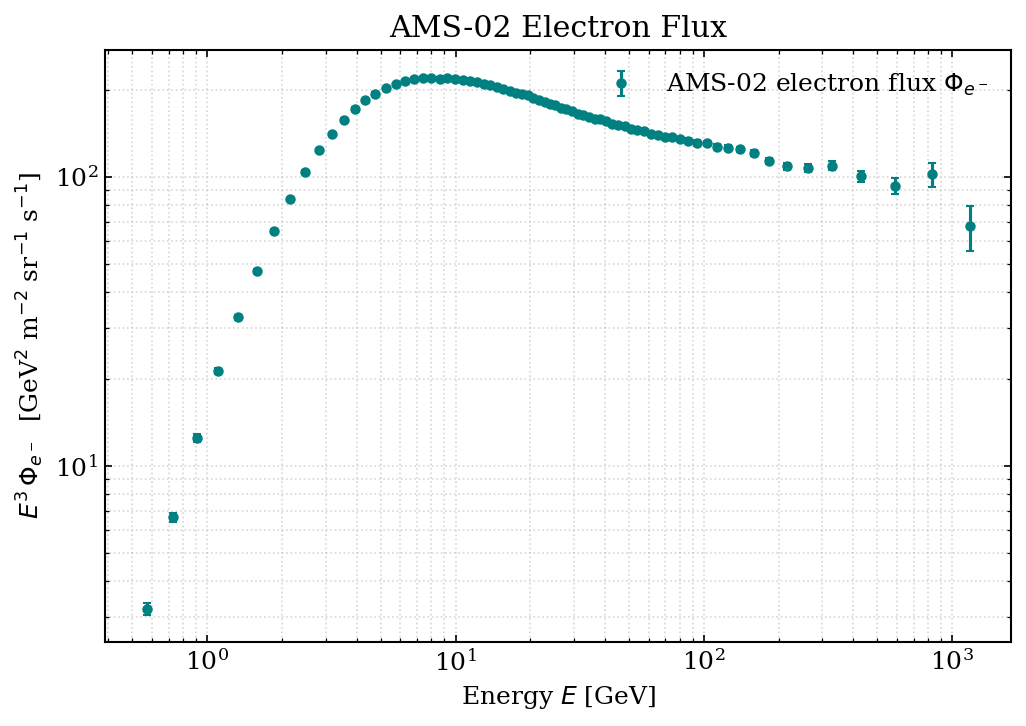

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

E = electrons["E_mean"]
ax.errorbar(
    E, E**3 * electrons["flux"], yerr=E**3 * electrons["tot_err"],
    fmt="o", color="teal", ecolor="teal", markersize=4, capsize=2,
    label=r"AMS-02 electron flux $\Phi_{e^-}$"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy $E$ [GeV]")
ax.set_ylabel(r"$E^3\,\Phi_{e^-}$  [GeV$^2$ m$^{-2}$ sr$^{-1}$ s$^{-1}$]")
ax.set_title("AMS-02 Electron Flux")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/electron_flux.png", dpi=300)

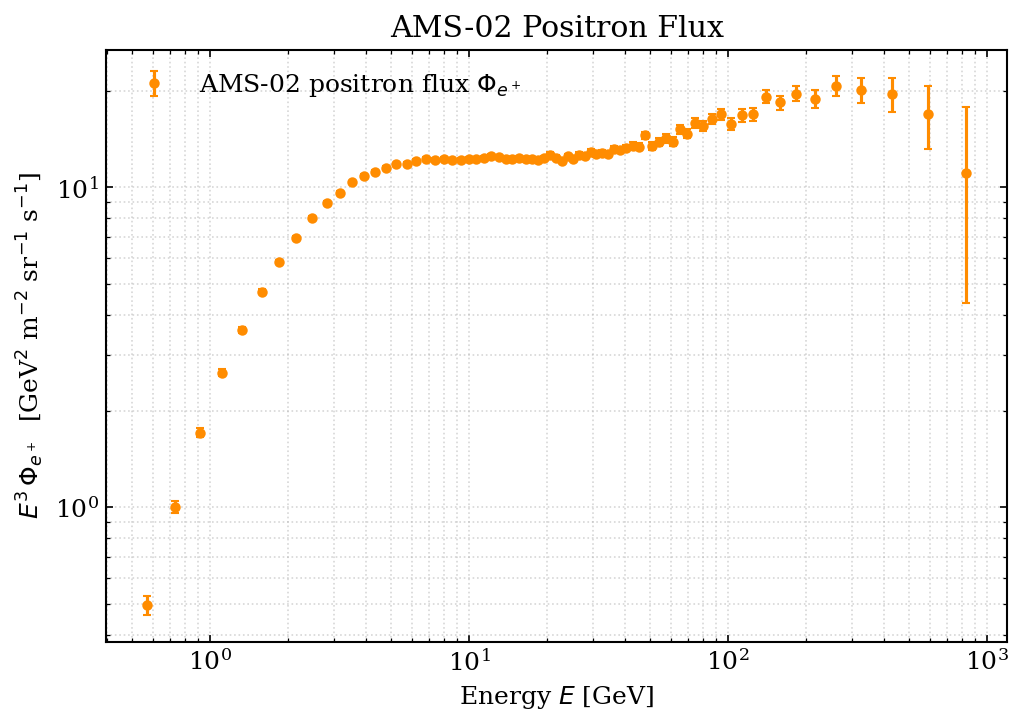

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

E = positrons["E_mean"]
ax.errorbar(
    E, E**3 * positrons["flux"], yerr=E**3 * positrons["tot_err"],
    fmt="o", color="darkorange", ecolor="darkorange", markersize=4, capsize=2,
    label=r"AMS-02 positron flux $\Phi_{e^+}$"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy $E$ [GeV]")
ax.set_ylabel(r"$E^3\,\Phi_{e^+}$  [GeV$^2$ m$^{-2}$ sr$^{-1}$ s$^{-1}$]")
ax.set_title("AMS-02 Positron Flux")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/positron_flux.png", dpi=300)

In [ ]:
def positron_fraction(flux_pos, flux_ele, err_pos, err_ele):
    """
    Compute the positron fraction and its propagated uncertainty
    assuming independent errors on flux_pos and flux_ele.
    """
    f, g = flux_pos, flux_ele
    sig_f, sig_g = err_pos, err_ele

    denom = f + g
    PF = f / denom

    sigma_PF = np.sqrt((g * sig_f)**2 + (f * sig_g)**2) / denom**2
    return PF, sigma_PF

merged["PF"], merged["PF_err"] = positron_fraction(
    merged["flux_pos"], merged["flux_ele"],
    merged["tot_err_pos"], merged["tot_err_ele"]
)

NameError: name 'merged' is not defined

Table-3 columns found -> ['energy_min GeV', 'energy_max GeV', 'energy_mean GeV', 'energy_mean_error_systematic_total GeV', 'positron_fraction', 'positron_fraction_error_statistical', 'positron_fraction_error_systematic_total']


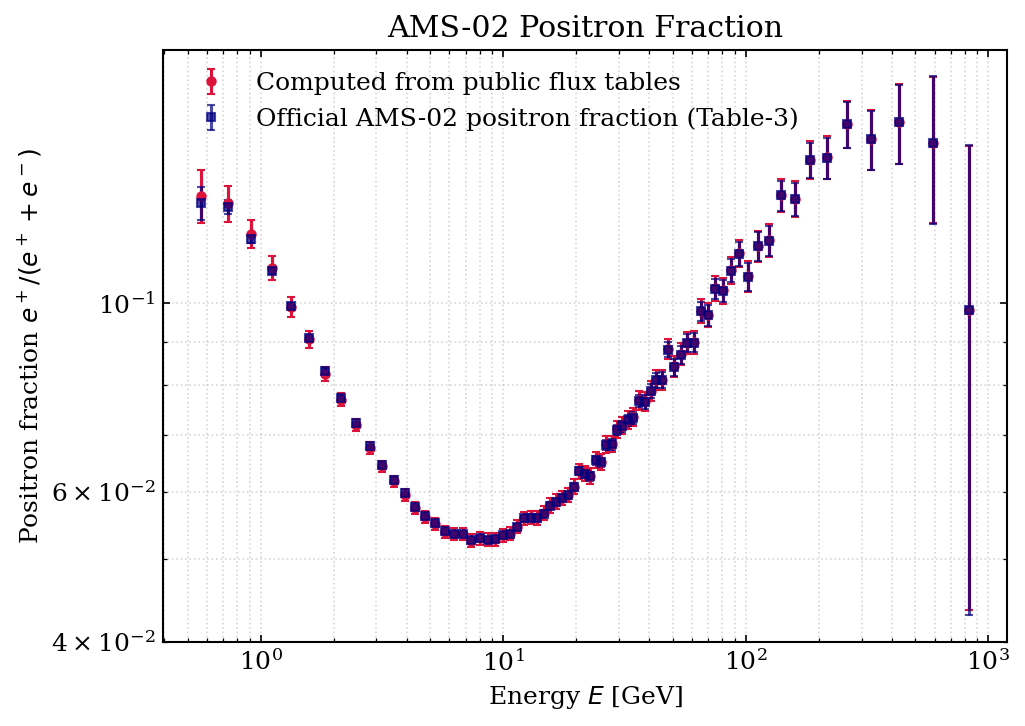

In [ ]:
official_pf = pd.read_csv("data/table-3.csv")
print("Table-3 columns found ->", list(official_pf.columns))


e_col_pf = official_pf.columns[2]
pf_col = official_pf.columns[4]
pf_stat_col = official_pf.columns[5]
pf_syst_col = official_pf.columns[6]
pf_err = np.sqrt(official_pf[pf_stat_col]**2 + official_pf[pf_syst_col]**2)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    merged["E_mean"], merged["PF"], yerr=merged["PF_err"],
    fmt="o", color="crimson", ecolor="crimson", markersize=4,
    capsize=2, label="Computed from public flux tables"
)
ax.errorbar(
    official_pf[e_col_pf], official_pf[pf_col], yerr=pf_err,
    fmt="s", color="navy", ecolor="navy", markersize=4, capsize=2,
    alpha=0.7, label="Official AMS-02 positron fraction (Table-3)"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy $E$ [GeV]")
ax.set_ylabel(r"Positron fraction $e^+/(e^+ + e^-)$")
ax.set_title("AMS-02 Positron Fraction")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/positron_fraction.png", dpi=300)

In [ ]:
def load_nuclei_table(path):
    """
    Load a Table-5 (proton), Table-7 (helium), or similar rigidity-binned
    AMS-02 CSV. As with the lepton tables, the rigidity and flux columns
    are read by position from the real downloaded files, and the
    statistical/systematic-error columns are found by keyword.
    """
    df = pd.read_csv(path)
    print(f"{path}: columns found -> {list(df.columns)}")

    r_col = df.columns[0]
    flux_col = df.columns[2]
    stat_col = _find_col(df.columns, "flux_error_statistical")
    total_syst_col = _find_col(df.columns, "flux_error_systematic_total")
    syst_component_cols = [c for c in df.columns
                            if any(k in c.lower() for k in ("acc", "unf", "scale"))]

    if flux_col is None or stat_col is None:
        raise ValueError(f"Could not identify flux/stat columns in {path}; "
                          f"inspect df.columns and adjust manually.")

    df = df.rename(columns={r_col: "E_mean", flux_col: "flux",
                             stat_col: "stat_err"})

    if total_syst_col is not None:
        df["syst_err"] = df[total_syst_col]
    elif syst_component_cols:
        df["syst_err"] = np.sqrt(sum(df[c].astype(float)**2
                                      for c in syst_component_cols))
    else:
        raise ValueError(f"No systematic-error column found in {path}.")

    df["tot_err"] = np.sqrt(df["stat_err"]**2 + df["syst_err"]**2)
    return df

In [ ]:
protons = load_nuclei_table("data/table-5.csv")
helium  = load_nuclei_table("data/table-7.csv")

data/table-5.csv: columns found -> ['rigidity_min GV', 'rigidity_max GV', 'proton_flux m^-2sr^-1s^-1GV^-1', 'proton_flux_error_statistical m^-2sr^-1s^-1GV^-1', 'proton_flux_error_acceptance m^-2sr^-1s^-1GV^-1', 'proton_flux_error_unfolding m^-2sr^-1s^-1GV^-1', 'proton_flux_error_rigidity_scale m^-2sr^-1s^-1GV^-1', 'proton_flux_error_systematic_total m^-2sr^-1s^-1GV^-1']
data/table-7.csv: columns found -> ['rigidity_min GV', 'rigidity_max GV', 'helium_flux m^-2sr^-1s^-1GV^-1', 'helium_flux_error_statistical m^-2sr^-1s^-1GV^-1', 'helium_flux_error_acceptance m^-2sr^-1s^-1GV^-1', 'helium_flux_error_unfolding m^-2sr^-1s^-1GV^-1', 'helium_flux_error_rigidity_scale m^-2sr^-1s^-1GV^-1', 'helium_flux_error_systematic_total m^-2sr^-1s^-1GV^-1']


In [ ]:
from scipy.optimize import curve_fit

def power_law(E, Phi0, gamma, E0=100.0):
    return Phi0 * (E / E0)**(-gamma)

def fit_power_law(E, flux, flux_err, E0=100.0):
    # Fit in log-space for numerically stable weighting when the
    # dynamic range of the flux spans many decades.
    def model(E, logPhi0, gamma):
        return logPhi0 - gamma * np.log10(E / E0)

    log_flux = np.log10(flux)
    log_err = flux_err / (flux * np.log(10))  # propagate to log-space

    popt, pcov = curve_fit(
        model, E, log_flux, sigma=log_err,
        p0=[np.log10(flux[0]), 2.7], absolute_sigma=True
    )
    logPhi0, gamma = popt
    Phi0 = 10**logPhi0
    perr = np.sqrt(np.diag(pcov))
    gamma_err = perr[1]
    return Phi0, gamma, gamma_err

Phi0_p, gamma_p, gamma_p_err = fit_power_law(
    protons["E_mean"].values, protons["flux"].values, protons["tot_err"].values
)
print(f"Proton spectral index: gamma = {gamma_p:.3f} +/- {gamma_p_err:.3f}")

Proton spectral index: gamma = 2.487 +/- 0.001


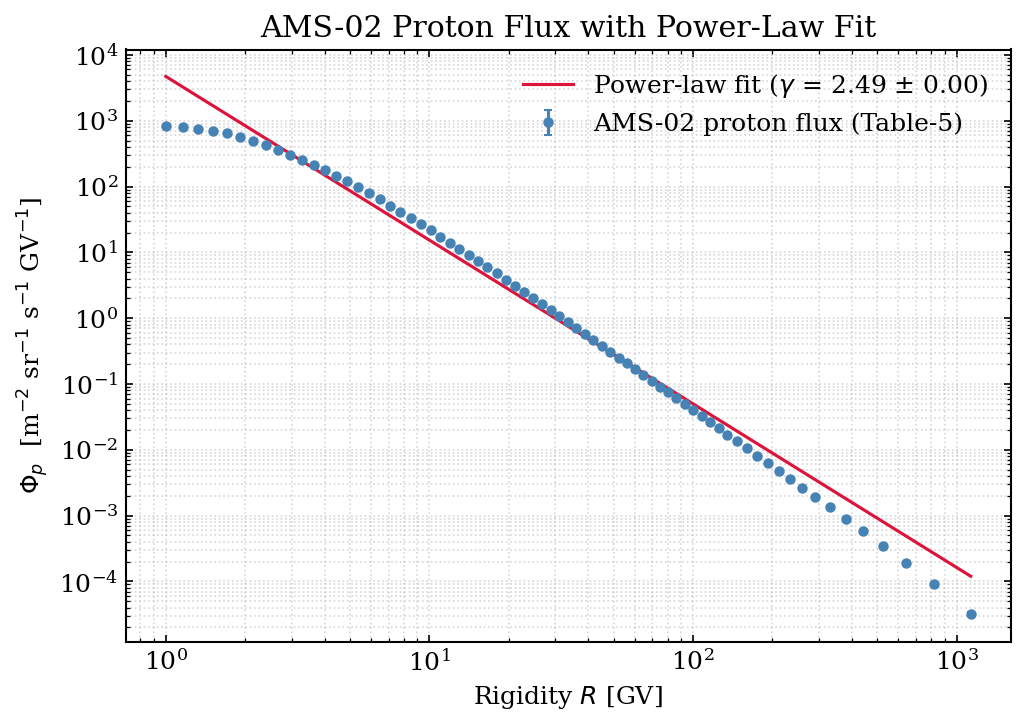

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    protons["E_mean"], protons["flux"], yerr=protons["tot_err"],
    fmt="o", color="steelblue", ecolor="steelblue", markersize=4,
    capsize=2, label="AMS-02 proton flux (Table-5)"
)

E_fine = np.logspace(np.log10(protons["E_mean"].min()),
                      np.log10(protons["E_mean"].max()), 200)
ax.plot(E_fine, power_law(E_fine, Phi0_p, gamma_p), "-", color="crimson",
        linewidth=1.5,
        label=fr"Power-law fit ($\gamma$ = {gamma_p:.2f} $\pm$ {gamma_p_err:.2f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rigidity $R$ [GV]")
ax.set_ylabel(r"$\Phi_p$  [m$^{-2}$ sr$^{-1}$ s$^{-1}$ GV$^{-1}$]")
ax.set_title("AMS-02 Proton Flux with Power-Law Fit")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/proton_flux_fit.png", dpi=300)

Helium spectral index: gamma = 2.523 +/- 0.001


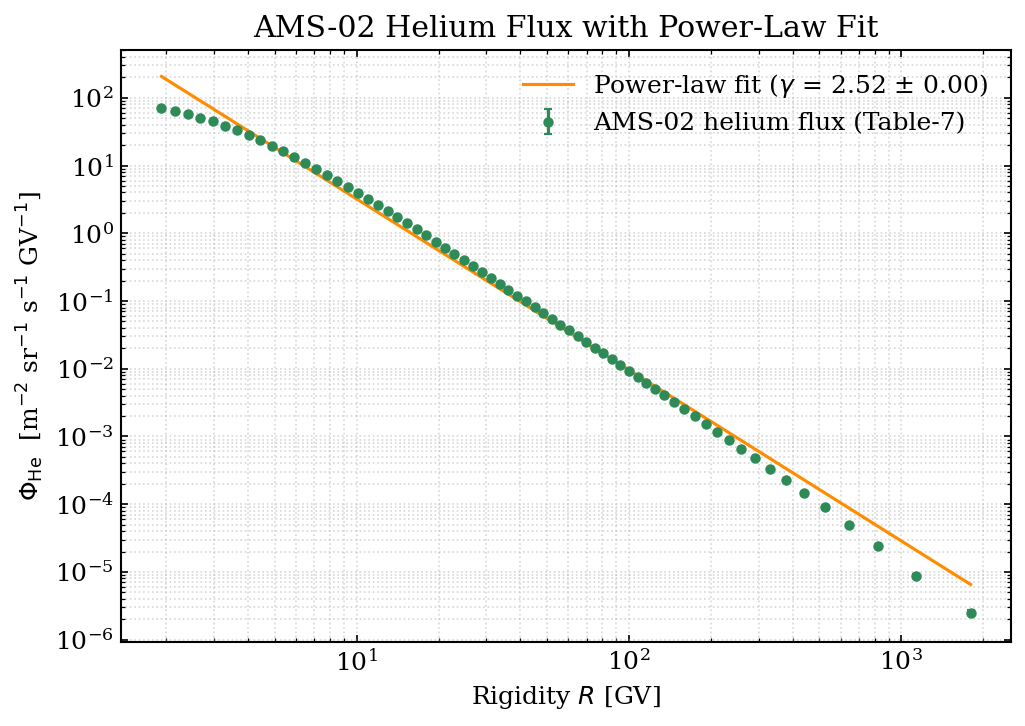

In [ ]:
Phi0_he, gamma_he, gamma_he_err = fit_power_law(
    helium["E_mean"].values, helium["flux"].values, helium["tot_err"].values
)
print(f"Helium spectral index: gamma = {gamma_he:.3f} +/- {gamma_he_err:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    helium["E_mean"], helium["flux"], yerr=helium["tot_err"],
    fmt="o", color="seagreen", ecolor="seagreen", markersize=4,
    capsize=2, label="AMS-02 helium flux (Table-7)"
)

E_fine = np.logspace(np.log10(helium["E_mean"].min()),
                      np.log10(helium["E_mean"].max()), 200)
ax.plot(E_fine, power_law(E_fine, Phi0_he, gamma_he), "-", color="darkorange",
        linewidth=1.5,
        label=fr"Power-law fit ($\gamma$ = {gamma_he:.2f} $\pm$ {gamma_he_err:.2f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rigidity $R$ [GV]")
ax.set_ylabel(r"$\Phi_{\rm He}$  [m$^{-2}$ sr$^{-1}$ s$^{-1}$ GV$^{-1}$]")
ax.set_title("AMS-02 Helium Flux with Power-Law Fit")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
Phi0_e, gamma_e, gamma_e_err = fit_power_law(electrons["E_mean"].values, electrons["flux"].values,
                          electrons["tot_err"].values)fig.savefig("figures/helium_flux_fit.png", dpi=300)

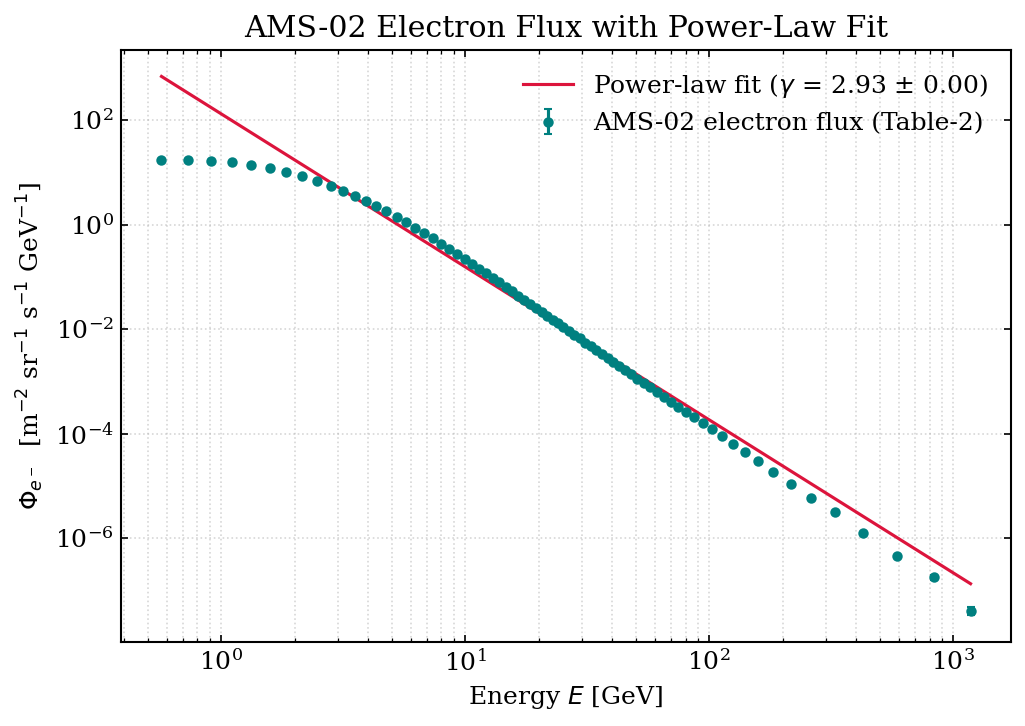

In [ ]:
Phi0_e, gamma_e, gamma_e_err = fit_power_law(electrons["E_mean"].values, electrons["flux"].values,
                          electrons["tot_err"].values)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    electrons["E_mean"], electrons["flux"], yerr=electrons["tot_err"],
    fmt="o", color="teal", ecolor="teal", markersize=4,
    capsize=2, label="AMS-02 electron flux (Table-2)"
)

E_fine = np.logspace(np.log10(electrons["E_mean"].min()),
                      np.log10(electrons["E_mean"].max()), 200)
ax.plot(E_fine, power_law(E_fine, Phi0_e, gamma_e), "-", color="crimson",
        linewidth=1.5,
        label=fr"Power-law fit ($\gamma$ = {gamma_e:.2f} $\pm$ {gamma_e_err:.2f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy $E$ [GeV]")
ax.set_ylabel(r"$\Phi_{e^-}$  [m$^{-2}$ sr$^{-1}$ s$^{-1}$ GeV$^{-1}$]")
ax.set_title("AMS-02 Electron Flux with Power-Law Fit")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/electron_flux_fit.png", dpi=300)


In [ ]:


print(f"Proton   gamma = {gamma_p:.3f} +/- {gamma_p_err:.3f}")
print(f"Helium   gamma = {gamma_he:.3f} +/- {gamma_he_err:.3f}")
print(f"Electron gamma = {gamma_e:.3f} +/- {gamma_e_err:.3f}")

Proton   gamma = 2.487 +/- 0.001
Helium   gamma = 2.523 +/- 0.001
Electron gamma = 2.928 +/- 0.001


In [ ]:
def broken_power_law(E, Phi0, gamma1, gamma2, Eb, s=1.0, E0=100.0):
    dgamma = gamma2 - gamma1
    return (Phi0 * (E / E0)**(-gamma1)
            * (1 + (E / Eb)**(dgamma / s))**(-s))

popt, pcov = curve_fit(
    broken_power_law, protons["E_mean"], protons["flux"],
    p0=[protons["flux"].iloc[0], 2.8, 2.6, 300.0],
    sigma=protons["tot_err"], absolute_sigma=True, maxfev=10000
)
print("Break energy E_b =", popt[3], "GeV")

Break energy E_b = 3.652821507266178 GeV


KeyboardInterrupt: 

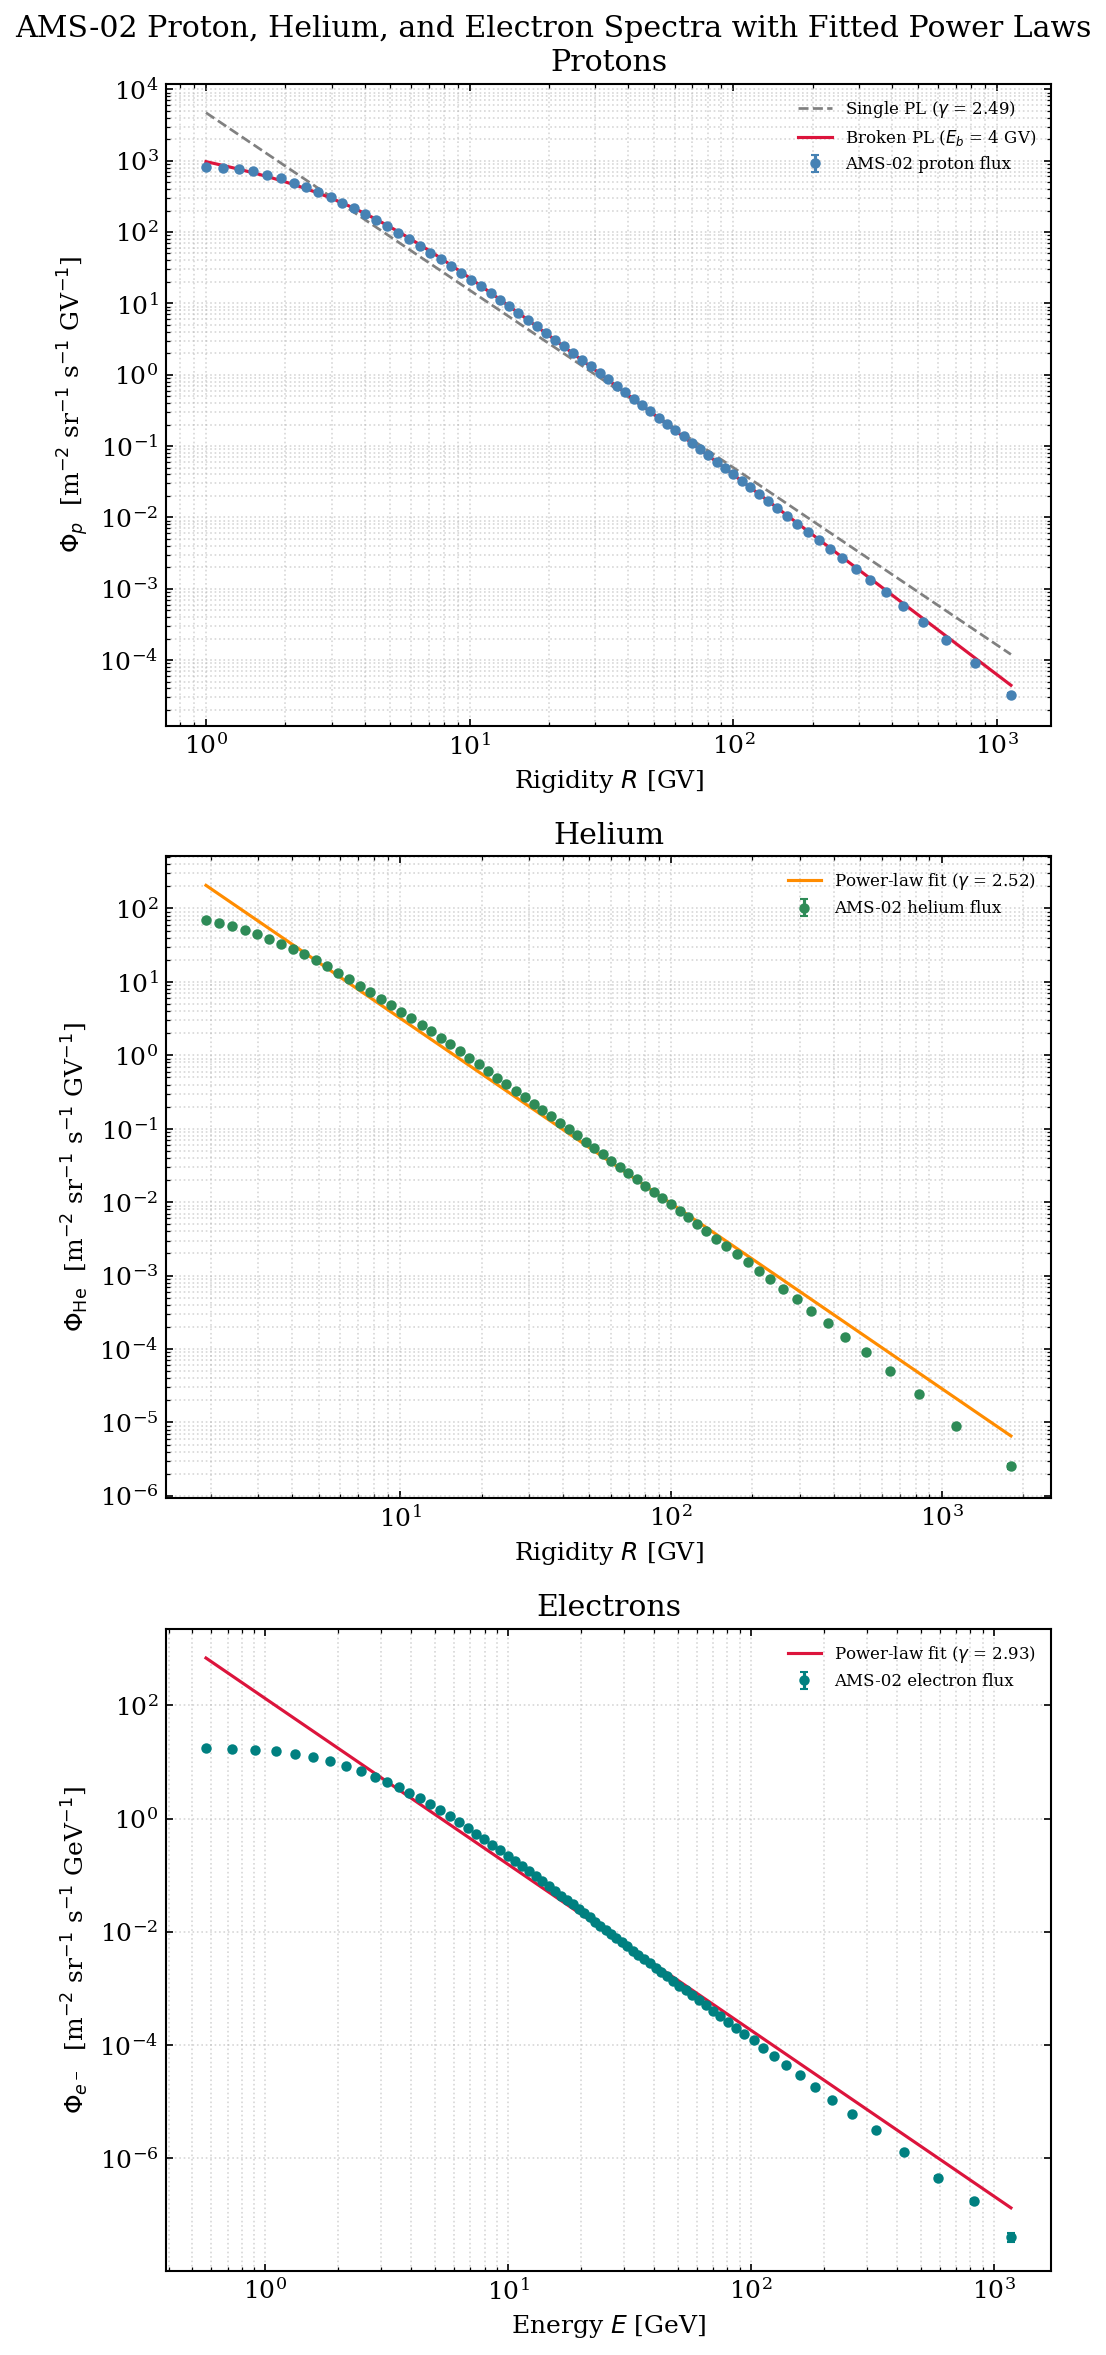

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(7, 16))

# --- Protons: single power law and broken power law ---
ax = axes[0]
ax.errorbar(protons["E_mean"], protons["flux"], yerr=protons["tot_err"],
            fmt="o", color="steelblue", ecolor="steelblue", markersize=4,
            capsize=2, label="AMS-02 proton flux")

E_fine_p = np.logspace(np.log10(protons["E_mean"].min()),
                        np.log10(protons["E_mean"].max()), 200)
ax.plot(E_fine_p, power_law(E_fine_p, Phi0_p, gamma_p), "--", color="gray",
        linewidth=1.3, label=fr"Single PL ($\gamma$ = {gamma_p:.2f})")
ax.plot(E_fine_p, broken_power_law(E_fine_p, *popt), "-", color="crimson",
        linewidth=1.5,
        label=fr"Broken PL ($E_b$ = {popt[3]:.0f} GV)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rigidity $R$ [GV]")
ax.set_ylabel(r"$\Phi_p$  [m$^{-2}$ sr$^{-1}$ s$^{-1}$ GV$^{-1}$]")
ax.set_title("Protons")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(fontsize=8)

# --- Helium: single power law ---
ax = axes[1]
ax.errorbar(helium["E_mean"], helium["flux"], yerr=helium["tot_err"],
            fmt="o", color="seagreen", ecolor="seagreen", markersize=4,
            capsize=2, label="AMS-02 helium flux")

E_fine_he = np.logspace(np.log10(helium["E_mean"].min()),
                         np.log10(helium["E_mean"].max()), 200)
ax.plot(E_fine_he, power_law(E_fine_he, Phi0_he, gamma_he), "-",
        color="darkorange", linewidth=1.5,
        label=fr"Power-law fit ($\gamma$ = {gamma_he:.2f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rigidity $R$ [GV]")
ax.set_ylabel(r"$\Phi_{\rm He}$  [m$^{-2}$ sr$^{-1}$ s$^{-1}$ GV$^{-1}$]")
ax.set_title("Helium")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(fontsize=8)

# --- Electrons: single power law ---
ax = axes[2]
ax.errorbar(electrons["E_mean"], electrons["flux"], yerr=electrons["tot_err"],
            fmt="o", color="teal", ecolor="teal", markersize=4,
            capsize=2, label="AMS-02 electron flux")

E_fine_e = np.logspace(np.log10(electrons["E_mean"].min()),
                        np.log10(electrons["E_mean"].max()), 200)
ax.plot(E_fine_e, power_law(E_fine_e, Phi0_e, gamma_e), "-", color="crimson",
        linewidth=1.5, label=fr"Power-law fit ($\gamma$ = {gamma_e:.2f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy $E$ [GeV]")
ax.set_ylabel(r"$\Phi_{e^-}$  [m$^{-2}$ sr$^{-1}$ s$^{-1}$ GeV$^{-1}$]")
ax.set_title("Electrons")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(fontsize=8)

fig.suptitle("AMS-02 Proton, Helium, and Electron Spectra with Fitted Power Laws")
fig.tight_layout()
fig.savefig("figures/all_spectra_with_fits.png", dpi=300)

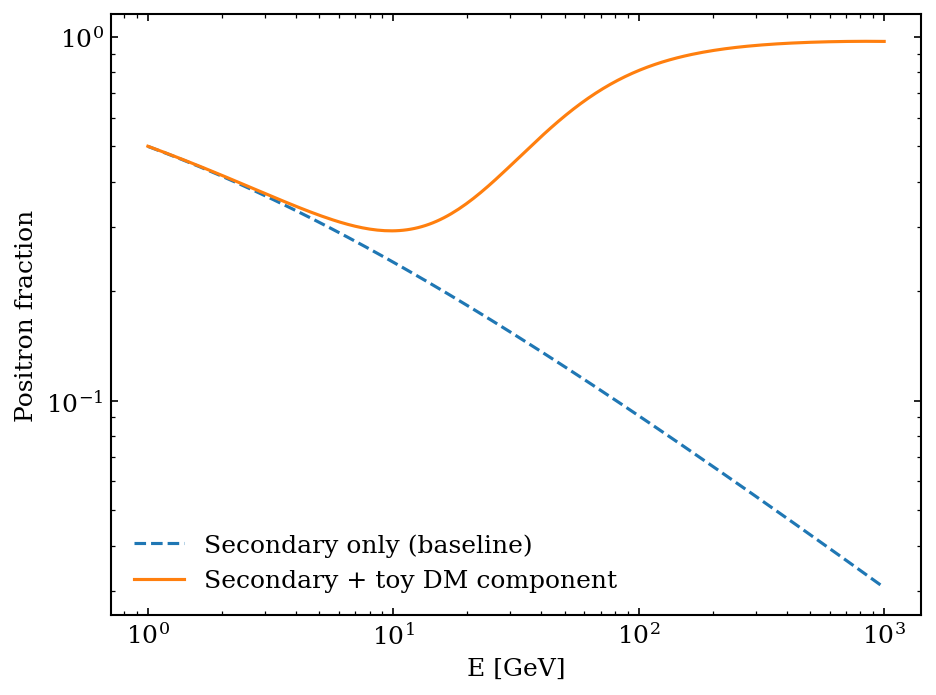

In [ ]:
def toy_secondary_positron(E, A_sec=1.0, delta=0.6):

    return A_sec * E**(-3.0 - delta)

def toy_dm_positron(E, A_dm, alpha, E_cut):

    return A_dm * E**(-alpha) * np.exp(-E / E_cut)

def toy_electron(E, A_e=1.0, gamma_e=3.1):
    return A_e * E**(-gamma_e)

E_grid = np.logspace(0, 3, 200)
e_plus_sec = toy_secondary_positron(E_grid)
e_plus_dm  = toy_dm_positron(E_grid, A_dm=2e-3, alpha=1.4, E_cut=500.0)
e_minus    = toy_electron(E_grid)

PF_secondary_only = e_plus_sec / (e_plus_sec + e_minus)
PF_with_dm = (e_plus_sec + e_plus_dm) / (e_plus_sec + e_plus_dm + e_minus)

plt.loglog(E_grid, PF_secondary_only, "--", label="Secondary only (baseline)")
plt.loglog(E_grid, PF_with_dm, "-", label="Secondary + toy DM component")
plt.xlabel("E [GeV]"); plt.ylabel("Positron fraction")
plt.legend(); plt.tight_layout()